# 3) Calculate eddy FKE

**Input: output from 2_preprocess_eddies.ipynb**

**Output: .nc file of the eddy contribution to FKE**


If you want to calculate the non-eddy contribution to FKE you can either calculate eddyFKE and subtractit from the full FKE or change the code to mask out the eddies instead of the background


In [1]:
import numpy as np
import xarray as xr
import dask
import dask.array as da
from dask.distributed import Client, LocalCluster
from matplotlib.path import Path
import os
import zarr
import copy


In [16]:
eke_path = "/scratch/b/b382615/eddies/"
model = "ICON"
icon_eke = xr.open_zarr(eke_path + "ICON_hist_GS.zarr", chunks={})



print(icon_eke)

**Read in the created .zarr file**

In [19]:
# track_path = "/work/bk1377/b382618/model_eddy_eval/historical/hadgem_hh4/1993-2015_v1/"
path = "/scratch/b/b382618/eeke/" + "consolidated_tracks_reindexed_" + model + "_final.zarr" 
ds_tracks = zarr.open(path, mode='r')

**this code makes your large .zarr file into a mask to then apply to the eke fields**

takes 2-3h for 22y of daily data

In [7]:
import numpy as np
import cv2
import zarr
import os

# 2. Setup output Zarr parameters
start_day = 0
end_day = 8034 # how many days I have in my ds
num_days = (end_day - start_day) + 1

lons = icon_eke.lon.values
lats = icon_eke.lat.values
nlat, nlon = len(lats), len(lons)

zarr_path = "/scratch/b/b382618/eeke/eddy_mask_"+ model +".zarr"

# Create the Zarr dataset
mask_zarr = zarr.open(
    zarr_path, 
    mode='w', 
    shape=(num_days, nlat, nlon), 
    chunks=(1, nlat, nlon), 
    dtype='i1'
)

# Pre-calculate scaling factors
lon_min, lon_range = lons.min(), lons.max() - lons.min()
lat_min, lat_range = lats.min(), lats.max() - lats.min()

print(f"Generating masks and saving to Zarr: {zarr_path}")

for i, day_idx in enumerate(range(start_day, end_day + 1)):
    print(f"Processing day {day_idx} (Slice {i})...")
    
    c_lons_raw = ds_tracks['effective_contour_longitude'][:, day_idx, :]
    c_lats_raw = ds_tracks['effective_contour_latitude'][:, day_idx, :]
    
    actual_num_eddies = c_lons_raw.shape[0]
    
    mask = np.ones((nlat, nlon), dtype=np.int8)
    all_polygons = []
    
    for j in range(actual_num_eddies):
        clon, clat = c_lons_raw[j], c_lats_raw[j]
        
        if np.any(np.isnan(clon)):
            continue
            
        # Draw the polygon 3 times to handle the wrap-around seam.
        # Most versions will fall off the map and be ignored by OpenCV.
        # The version that hits the boundary will have its "overflow" 
        # drawn correctly on the opposite side of the mask.
        for offset in [-360, 0, 360]:
            px = (((clon + offset) - lon_min) / lon_range * (nlon - 1)).astype(np.int32)
            py = ((clat - lat_min) / lat_range * (nlat - 1)).astype(np.int32)
            
            # Optimization: Only add polygons that actually touch the grid space
            if np.any((px >= -nlon) & (px <= 2*nlon)):
                all_polygons.append(np.column_stack([px, py]))
    
    if all_polygons:
        # Drawing multiple times on the same mask doesn't double the data,
        # it just fills the 1s with 0s in the correct pixel locations.
        cv2.fillPoly(mask, all_polygons, 0)
    
    mask_zarr[i, :, :] = mask

print("Zarr generation complete without index errors")

Generating masks and saving to Zarr: /scratch/b/b382618/eeke/eddy_0masks_combined_all_HADGEM-MM.zarr
Processing day 0 (Slice 0)...
Processing day 1 (Slice 1)...
Processing day 2 (Slice 2)...
Processing day 3 (Slice 3)...
Processing day 4 (Slice 4)...
Processing day 5 (Slice 5)...
Processing day 6 (Slice 6)...
Processing day 7 (Slice 7)...
Processing day 8 (Slice 8)...
Processing day 9 (Slice 9)...
Processing day 10 (Slice 10)...
Processing day 11 (Slice 11)...
Processing day 12 (Slice 12)...
Processing day 13 (Slice 13)...
Processing day 14 (Slice 14)...
Processing day 15 (Slice 15)...
Processing day 16 (Slice 16)...
Processing day 17 (Slice 17)...
Processing day 18 (Slice 18)...
Processing day 19 (Slice 19)...
Processing day 20 (Slice 20)...
Processing day 21 (Slice 21)...
Processing day 22 (Slice 22)...
Processing day 23 (Slice 23)...
Processing day 24 (Slice 24)...
Processing day 25 (Slice 25)...
Processing day 26 (Slice 26)...
Processing day 27 (Slice 27)...
Processing day 28 (Slic

**this code now applies the masks you made in previous step to the eke fields**

In [20]:
import numpy as np
import zarr
import xarray as xr

# 1. Open the existing mask Zarr ARRAY directly
mask_zarr_path = "/scratch/b/b382618/eeke/eddy_mask_" + model + ".zarr"
mask_array = zarr.open(mask_zarr_path, mode='r')
# Print the full shape to see all dimensions
print(f"The Zarr array shape is: {mask_array.shape}")

# Print just the time dimension (first element)
print(f"Number of time steps: {mask_array.shape[0]}")
# 2. Setup output EKE Zarr
start_day = 0
end_day = 8034 
num_days = (end_day - start_day) + 1

lons = icon_eke.lon.values
lats = icon_eke.lat.values
nlat, nlon = len(lats), len(lons)

eke_out_path = "/scratch/b/b382618/eeke/eddy_with_eke_0_" + model + ".zarr"

# Create the output array
eke_zarr_out = zarr.open(
    eke_out_path, 
    mode='w', 
    shape=(num_days, nlat, nlon), 
    chunks=(1, nlat, nlon), 
    dtype='f4'
)

print(f"Applying inverse masks from {mask_zarr_path} to EKE...")

step_size = 100 
for start in range(0, num_days, step_size):
    end = min(start + step_size, num_days)
    print(f"Processing days {start} to {end-1}...")

    # A. Bulk load EKE values
    eke_block = icon_eke['EKE'].isel(time=slice(start, end)).values
    
    # B. Load the corresponding mask block
    mask_block = mask_array[start:end, :, :]
    
    # C. Apply the INVERSE mask
    # This turns 1 into 0 and 0 into 1
    inverse_mask = 1 - mask_block
    eke_block = eke_block * inverse_mask
    
    # D. Write the entire block
    eke_zarr_out[start:end, :, :] = eke_block

print("Inverted masked EKE Zarr generation complete")

The Zarr array shape is: (8036, 721, 1440)
Number of time steps: 8036
Applying inverse masks from /scratch/b/b382618/eeke/eddy_0masks_combined_all_HADGEM-HH.zarr to EKE...
Processing days 0 to 99...
Processing days 100 to 199...
Processing days 200 to 299...
Processing days 300 to 399...
Processing days 400 to 499...
Processing days 500 to 599...
Processing days 600 to 699...
Processing days 700 to 799...
Processing days 800 to 899...
Processing days 900 to 999...
Processing days 1000 to 1099...
Processing days 1100 to 1199...
Processing days 1200 to 1299...
Processing days 1300 to 1399...
Processing days 1400 to 1499...
Processing days 1500 to 1599...
Processing days 1600 to 1699...
Processing days 1700 to 1799...
Processing days 1800 to 1899...
Processing days 1900 to 1999...
Processing days 2000 to 2099...
Processing days 2100 to 2199...
Processing days 2200 to 2299...
Processing days 2300 to 2399...
Processing days 2400 to 2499...
Processing days 2500 to 2599...
Processing days 260

**sanity-check plot to see if the code is working in the way it should**

you should see 0 in the background and cut out eddies with eke pixels in them

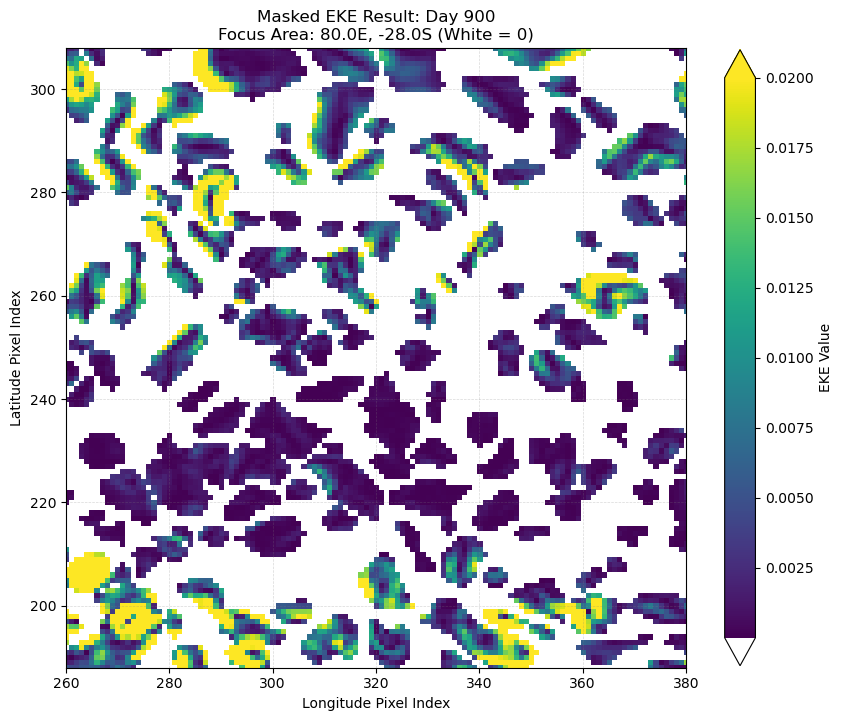

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import copy

# 1. Select the time slice (0 corresponds to start_day in your Zarr)
day_idx = 900
actual_day = 0 + day_idx

# Load the masked EKE data from your new output Zarr
eke_slice = eke_zarr_out[day_idx, :, :]

# 2. Define the zoom area using your specified coordinates
target_lon, target_lat = 80.0, -28.0

lon_min, lon_max = lons.min(), lons.max()
lat_min, lat_max = lats.min(), lats.max()
lon_range = lon_max - lon_min
lat_range = lat_max - lat_min

center_px = (target_lon - lon_min) / lon_range * (nlon - 1)
center_py = (target_lat - lat_min) / lat_range * (nlat - 1)
offset = 60 

# 3. Setup Colormap (0 = White)
current_cmap = copy.copy(plt.get_cmap('viridis'))
current_cmap.set_under('white')
current_cmap.set_bad(color='lightgrey') # For any land/NaNs

plt.figure(figsize=(10, 10))

# 4. Display the field
# vmin=1e-8 ensures the 0-values are rendered as white
im = plt.imshow(eke_slice, origin='lower', cmap=current_cmap, 
                vmin=1e-7, vmax=0.02, interpolation='none')

# 5. Apply the zoom focus
plt.xlim(center_px - offset, center_px + offset)
plt.ylim(center_py - offset, center_py + offset)

# 6. Formatting
plt.title(f"Masked EKE Result: Day {actual_day}\nFocus Area: {target_lon}E, {target_lat}S (White = 0)")
plt.colorbar(im, label="EKE Value", shrink=0.8, extend='both')
plt.xlabel("Longitude Pixel Index")
plt.ylabel("Latitude Pixel Index")
plt.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.3)

plt.show()

**another sanity-check**

you should see one plot with full eke field and one with cut out eddy eke. And in bothplots in red are the eddy polygons

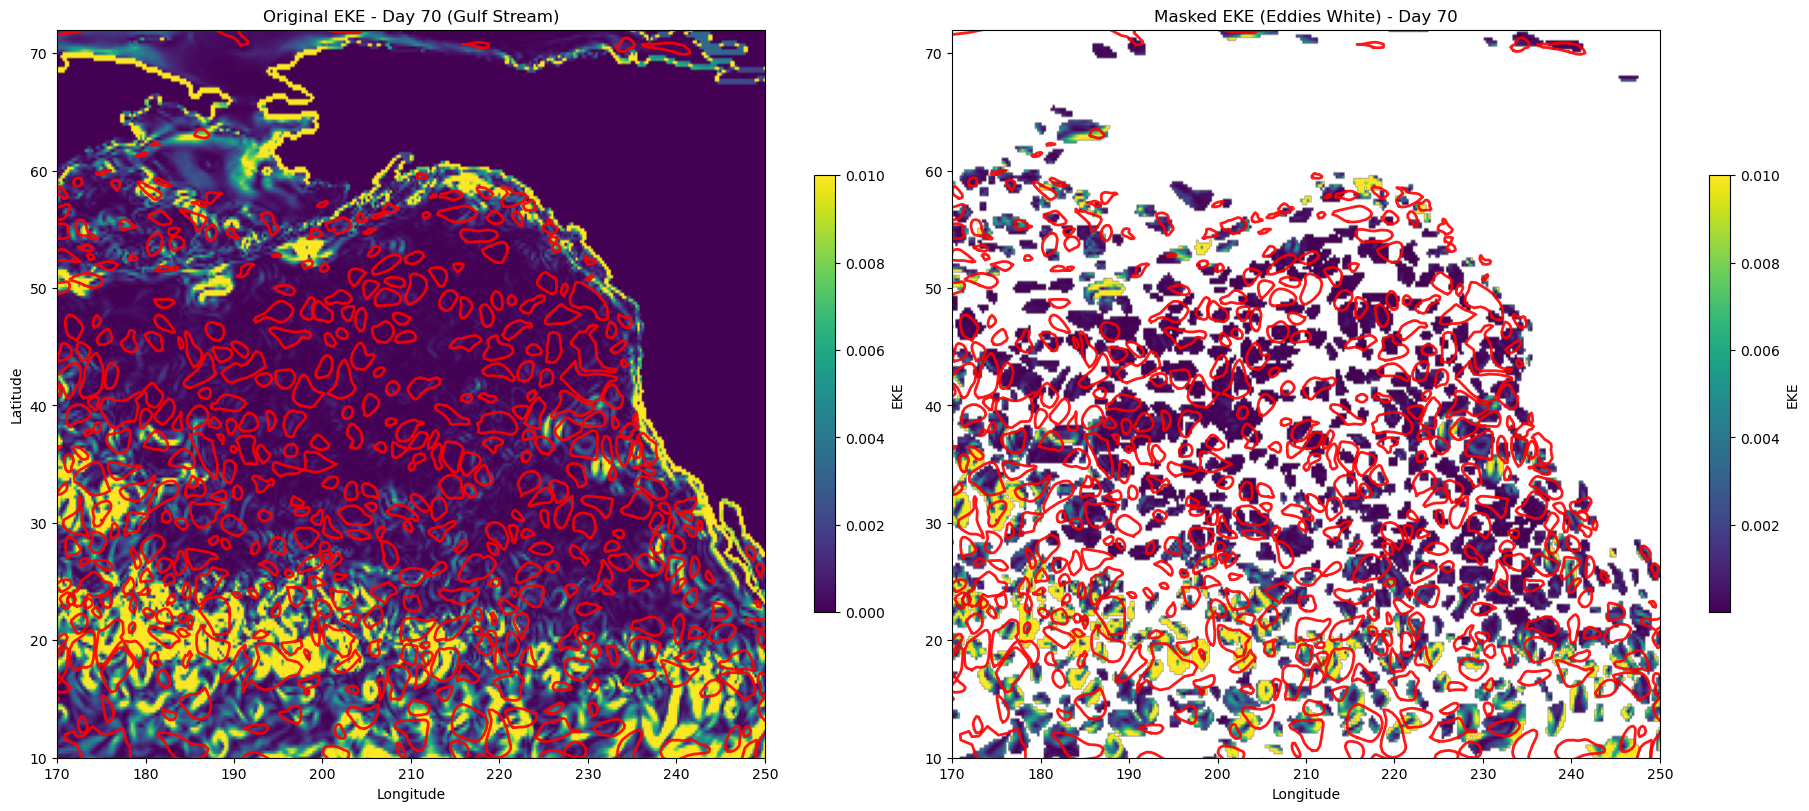

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import zarr
import xarray as xr

# 1. Load the data
eke_masked_ds = zarr.open("/scratch/b/b382618/eeke/eddy_with_eke_0_" + model + ".zarr", mode='r')

day_idx = 70

# 2. Extract Data
lons = icon_eke.lon.values
lats = icon_eke.lat.values

# def wrap_lon(lon):
#     return (lon + 180) % 360 - 180

# lons = wrap_lon(lons)
# sort_idx = np.argsort(lons)
# lons = lons[sort_idx]
orig_eke = icon_eke['EKE'].isel(time=day_idx).values
masked_eke_raw = eke_masked_ds[day_idx, :, :]

# Mask the zeros so they appear white
masked_eke_plot = np.ma.masked_equal(masked_eke_raw, 0)

# Contours for the overlay
c_lons = ds_tracks['effective_contour_longitude'][:, day_idx, :]
c_lats = ds_tracks['effective_contour_latitude'][:, day_idx, :]

# 3. Define Gulf Stream Bounds
lon_bounds = [170, 250]
lat_bounds = [10, 72]

# 4. Create the Comparison Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

# Left Plot: Original
im1 = ax1.imshow(orig_eke, origin='lower', cmap='viridis', aspect='auto', 
                 extent=extent, vmax=0.01)
ax1.set_title(f"Original EKE - Day {day_idx} (Gulf Stream)")
plt.colorbar(im1, ax=ax1, label='EKE', shrink=0.6)

# Right Plot: Masked
im2 = ax2.imshow(masked_eke_plot, origin='lower', cmap='viridis', aspect='auto', 
                 extent=extent, vmax=0.01)
ax2.set_title(f"Masked EKE (Eddies White) - Day {day_idx}")
plt.colorbar(im2, ax=ax2, label='EKE', shrink=0.6)

# Overlay contours
for j in range(c_lons.shape[0]):
    clon, clat = c_lons[j], c_lats[j]
    if not np.any(np.isnan(clon)):
        # Plotting on both
        ax1.plot(clon, clat, color='red', linewidth=2, alpha=0.9)
        ax2.plot(clon, clat, color='red', linewidth=2, alpha=0.9)

# Set the zoom/centering
for ax in [ax1, ax2]:
    ax.set_xlim(lon_bounds)
    ax.set_ylim(lat_bounds)
    ax.set_xlabel("Longitude")

ax1.set_ylabel("Latitude")

plt.show()

**last sanity check**

To see if it has worked globally

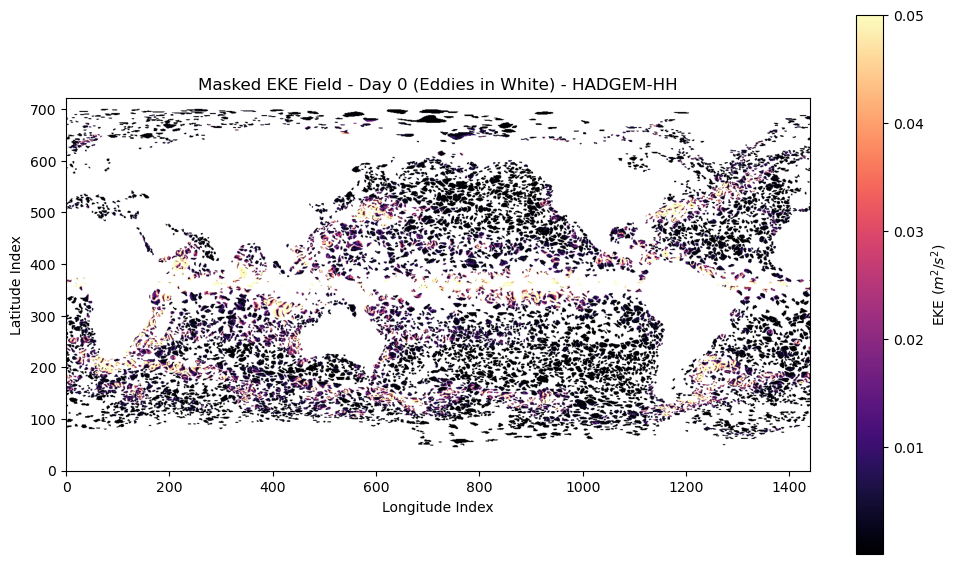

In [23]:
import zarr
import matplotlib.pyplot as plt
import numpy as np
import copy

# 1. Open the Zarr array directly in read mode
eke_array = zarr.open("/scratch/b/b382618/eeke/eddy_with_eke_0_"+ model +".zarr", mode='r')

# 2. Select the first day (index 0)
data_to_plot = eke_array[1000, :, :].astype(np.float32)

# --- THE WHITE MASK FIX ---
# Create a masked array where 0 is treated as "invalid"
data_masked = np.ma.masked_where(data_to_plot == 0, data_to_plot)

# Get the 'magma' colormap and set the color for masked values (the zeros)
current_cmap = copy.copy(plt.get_cmap('magma'))
current_cmap.set_bad(color='white')
# --------------------------

# 3. Create the plot
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Set background to gray or keep it white (set_bad will override for the zeros)
ax.set_facecolor('0.8') 

# Use imshow with the masked data and updated colormap
im = ax.imshow(
    data_masked, 
    cmap=current_cmap, 
    vmin=0.0001, # Start slightly above 0 to keep the contrast
    vmax=0.05, 
    origin='lower'
)

plt.colorbar(im, label='EKE ($m^2/s^2$)')
plt.title(f"Masked EKE Field - Day 0 (Eddies in White) - {model}")
plt.xlabel("Longitude Index")
plt.ylabel("Latitude Index")

plt.show()

**Now we average over all the time steps to get the eddy component of EKE**

Calculating mean with NaN poisoning (Any NaN makes the result NaN)...
Discarded 89 days: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 7991, 7992, 7993, 7994, 7995, 7996, 7997, 7998, 7999, 8000, 8001, 8002, 8003, 8004, 8005, 8006, 8007, 8008, 8009, 8010, 8011, 8012, 8013, 8014, 8015, 8016, 8017, 8018, 8019, 8020, 8021, 8022, 8023, 8024, 8025, 8026, 8027, 8028, 8029, 8030, 8031, 8032, 8033, 8034]


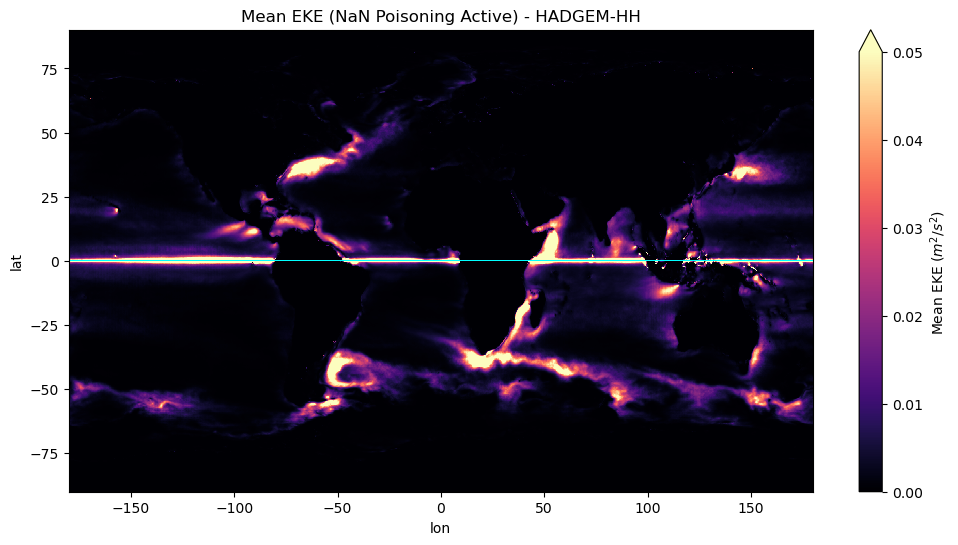

In [24]:

# 1. Open the Zarr array
eke_out_path = "/scratch/b/b382618/eeke/eddy_with_eke_0_"+ model +".zarr"
eke_store = zarr.open(eke_out_path, mode='r')
lons, lats = icon_eke.lon.values, icon_eke.lat.values
num_days, h, w = eke_store.shape

# 2. Accumulate with "NaN poisoning"
# Initialize with zeros. 
# As soon as a NaN is added to a pixel, that pixel becomes NaN permanently.
sum_array = np.zeros((h, w), dtype=np.float32)
discarded_days = []
valid_days_count = 0

print("Calculating mean with NaN poisoning (Any NaN makes the result NaN)...")

for i in range(num_days):
    slice_data = eke_store[i, :, :].astype(np.float32)
    
    # Check if the whole field is empty/zeroed out
    if np.all(np.isnan(slice_data)) or np.all(slice_data == 0):
        discarded_days.append(i)
        continue
    
    # Direct addition: No nan_to_num. 
    # If slice_data has a NaN at [y, x], sum_array[y, x] becomes NaN.
    sum_array += slice_data
    valid_days_count += 1

# 3. Final Mean
# Even if valid_days_count is 1000, if a pixel was NaN once, 
# the sum is NaN, and NaN / 1000 is still NaN.
if valid_days_count > 0:
    mean_2d = sum_array / valid_days_count
else:
    mean_2d = np.full((h, w), np.nan)

print(f"Discarded {len(discarded_days)} days: {discarded_days}")

# 4. Save and Plot
final_da = xr.DataArray(
    mean_2d,
    coords=[("lat", lats), ("lon", lons)],
    name="background_eke_poisoned"
)

final_da.to_netcdf("eddy_contribution_"+model+".nc") 

# Shift and Plot
final_da_shifted = final_da.assign_coords(lon=(((final_da.lon + 180) % 360) - 180)).sortby('lon')
current_cmap = copy.copy(plt.get_cmap('magma'))
current_cmap.set_bad(color='cyan') 

plt.figure(figsize=(12, 6))
final_da_shifted.plot(
    cmap=current_cmap, 
    vmin=0, 
    vmax=0.05, 
    robust=True,
    cbar_kwargs={'label': 'Mean EKE ($m^2/s^2$)'}
)

plt.title(f"Mean EKE (NaN Poisoning Active) - {model}")
plt.show()

**now calculate the difference from Eddy EKE and full EKE**

just to check that it all makes sense = alleke-eddy_contribution should always be positive

In [11]:
eddy = xr.open_dataset("eddy_contribution_"+model+".nc")
alleke = xr.open_dataset("/home/b/b382618/notebooks/paper1/field_files/eke/icon_mean_eke.nc")

/home/b/b382618/.conda/envs/eddy_env/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
## usually you will need to interpolate to subtract the fields because we were not careful with making identical xarray files
alleke= alleke.interp_like(eddy)


NameError: name 'alleke' is not defined

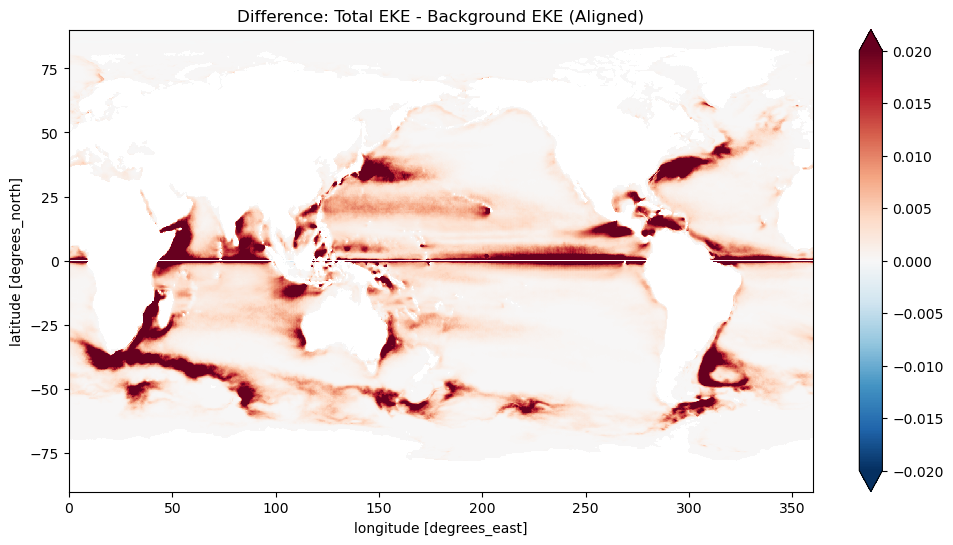

In [15]:

# 3. Perform the subtraction
# We use the specific DataArrays to avoid naming conflicts
eddy_cal = alleke['zos'] - eddy['background_eke_poisoned']

# 4. Plot the result
plt.figure(figsize=(12, 6))
eddy_cal.plot(cmap='RdBu_r', robust=True, vmax= 0.02)
plt.title("Difference: Total EKE - Eddy EKE")
plt.show()

# Optional: Save the result
# diff.to_netcdf("eke_difference_" + model + ".nc")